In [1]:
# Imports

import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)


In [2]:
# Import cleaned CSV

filepath = "../data/spike_waveforms_clean.csv"

df = pd.read_csv(
    filepath,
    header=None
)

print("Shape:", df.shape)
display(df.head())


Shape: (26862, 62)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61
0,28.708333,24.775000,2.341667,0.741667,12.741667,0.708333,-11.291667,-10.891667,2.308333,-0.891667,-6.491667,-11.358333,-27.391667,-23.858333,-15.425000,-13.358333,-2.091667,2.241667,13.008333,35.475000,43.541667,54.775000,69.975000,71.608333,85.575000,86.375000,84.008333,86.408333,75.175000,88.808333,96.408333,3392.475,3289.441667,2714.641667,2339.641667,2006.508333,1767.541667,1590.408333,1441.041667,1287.075000,1162.475000,1005.008333,894.108333,792.775000,704.975000,577.275000,470.608333,381.641667,300.275000,237.808333,176.108333,108.441667,52.741667,19.941667,-11.258333,8.741667,1.508333,-37.425000,-87.458333,-107.858333,-139.025000,-140.758333
1,32.623333,14.990000,5.756667,16.190000,2.623333,4.156667,2.923333,16.623333,11.323333,-10.710000,-16.710000,-4.643333,-9.843333,-23.376667,-15.776667,-8.276667,-9.043333,-12.643333,0.890000,2.923333,22.156667,4.090000,-17.176667,-39.576667,-166.676667,-271.710000,-293.310000,-304.643333,-259.676667,-127.776667,18.956667,150.690,256.756667,347.756667,382.590000,372.523333,329.223333,300.790000,255.523333,206.656667,183.423333,147.856667,85.356667,61.356667,36.190000,24.156667,4.923333,-3.843333,3.756667,-10.643333,-32.376667,-32.776667,-35.976667,-12.776667,-16.310000,-1.110000,0.156667,8.956667,8.090000,4.890000,3.290000,7.356667
2,-32.421667,-33.255000,-18.421667,-8.455000,-12.821667,-4.821667,-12.088333,11.111667,21.945000,24.778333,0.811667,3.645000,24.478333,24.811667,4.378333,-16.388333,-7.555000,1.578333,4.345000,24.345000,52.845000,41.245000,37.678333,-14.021667,-124.155000,-215.221667,-230.988333,-216.521667,-187.521667,-109.821667,0.711667,120.545,226.611667,290.245000,299.845000,296.211667,262.211667,230.578333,213.378333,192.611667,179.711667,158.511667,132.111667,128.111667,108.545000,75.711667,30.145000,28.545000,36.511667,18.078333,16.878333,37.278333,39.345000,35.345000,34.478333,14.478333,8.845000,9.645000,2.111667,-15.121667,-16.788333,0.411667
3,-14.938333,-31.405000,-10.438333,-1.605000,-11.271667,-16.671667,-21.405000,-11.038333,-1.338333,-5.305000,12.328333,10.695000,25.561667,34.328333,25.928333,-3.271667,12.361667,11.195000,-0.838333,-2.871667,-8.938333,11.528333,-11.338333,-59.538333,-131.338333,-183.805000,-259.838333,-323.471667,-297.138333,-203.071667,-51.771667,82.495,171.861667,229.895000,256.728333,260.295000,250.661667,208.595000,188.995000,165.428333,138.561667,100.528333,60.795000,52.028333,44.828333,35.561667,27.161667,5.861667,11.995000,-7.738333,-2.971667,-8.505000,-19.338333,7.561667,24.461667,25.661667,11.261667,9.261667,-5.238333,-28.171667,-32.971667,-29.005000
4,-5.021667,-0.588333,7.811667,15.845000,10.611667,8.211667,0.578333,-1.388333,27.411667,17.378333,9.811667,1.811667,-8.621667,-0.988333,-1.021667,-1.788333,-9.821667,-13.788333,-25.821667,-30.621667,-27.821667,-33.421667,-43.421667,-45.021667,-36.188333,-36.221667,-27.421667,-31.021667,5.845000,47.878333,-298.355000,-366.855,-274.255000,-156.221667,40.245000,171.345000,163.778333,107.178333,62.278333,35.011667,22.245000,15.811667,23.011667,19.045000,13.045000,-16.188333,-22.955000,-28.188333,-30.621667,-17.388333,-6.988333,-19.021667,-17.021667,-32.221667,-38.621667,-28.621667,-26.621667,-10.621667,-20.221667,-11.421667,-16.621667,-24.221667


In [3]:
# Define sampling rate and time axis

sampling_rate_hz = 30000

time_ms = (
    np.arange(df.shape[1])
    / sampling_rate_hz
    * 1000
)

print("Number of neuron responses:", df.shape[0])
print("Samples per response:", df.shape[1])
print("Response duration, ms:", time_ms[-1])


Number of neuron responses: 26862
Samples per response: 62
Response duration, ms: 2.033333333333333


In [4]:
# Create output folder for TIFF files

tiff_output_dir = "../outputs/initial_plots_tiff"

os.makedirs(
    tiff_output_dir,
    exist_ok=True
)

print("TIFF output folder:")
print(tiff_output_dir)


TIFF output folder:
../outputs/initial_plots_tiff


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61
count,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000
mean,-5.7715,-4.9916,-2.7883,-0.7334,-0.2699,-0.4220,-0.4921,-0.3811,-0.4108,-0.7050,-0.8785,-0.5039,0.1232,0.6537,0.9250,1.4382,2.2089,3.0922,4.3081,5.5987,6.6634,7.9059,9.1868,10.3933,12.3856,12.7625,6.4298,-6.2853,-31.3864,-78.3895,-150.1262,-168.9277,-136.8763,-57.6252,25.1601,90.3618,126.2835,141.0145,142.7721,137.7511,128.3968,115.5622,102.2421,89.5490,77.9092,67.6554,59.1792,51.6118,44.8818,38.9964,33.9038,29.3577,25.4955,22.2060,19.1285,16.0374,13.4731,11.5256,9.8432,7.2500,5.0280,-2.8528
std,141.9222,130.7526,118.9746,104.6710,90.5083,75.8795,64.2804,53.3735,45.1289,41.3486,42.3390,48.1828,55.9729,65.3697,75.3632,87.9229,103.5512,116.6921,130.3788,143.9803,158.6675,176.1490,199.3096,227.8242,258.6181,314.5927,384.7846,443.2288,515.2351,631.9229,787.1373,1060.3490,1140.7565,1010.3332,909.1027,853.4947,814.2156,785.0623,761.2411,741.4241,721.1840,697.9087,678.0304,661.2278,646.3544,633.6387,621.9233,611.1378,600.6341,590.3280,580.1579,570.6689,561.4571,552.1890,543.4709,534.5492,525.4472,516.5445,507.2004,498.6430,490.1045,487.8068
min,-3661.9650,-3457.2650,-2943.6650,-2626.6767,-2298.5767,-1716.8767,-1449.3650,-1238.6033,-1147.3167,-927.6667,-886.8667,-1018.0883,-1327.1233,-1470.9233,-1609.2900,-2323.9233,-2535.4233,-2617.6567,-2926.4567,-2957.2567,-2901.7567,-3118.2730,-3775.3917,-5314.3250,-5565.7517,-5977.7850,-6032.7183,-6056.3517,-6058.3850,-6047.1517,-6030.3183,-6020.7183,-6099.2550,-6105.6550,-6102.0550,-6112.0717,-6117.2717,-6100.8550,-6102.4550,-6102.8550,-6113.3267,-6125.6517,-6128.0517,-6129.6517,-6129.0383,-6179.3100,-6298.8433,-6392.1100,-6475.1433,-6551.2100,-6615.2767,-6661.3767,-6709.3767,-6741.0433,-6776.3433,-6804.0100,-6827.2100,-6837.2100,-6838.8100,-6847.2100,-6858.0433,-6872.4433
25%,-16.1129,-15.3878,-14.3075,-13.5792,-13.2729,-13.2829,-13.1563,-12.8996,-12.9146,-13.1875,-13.8158,-13.9882,-14.2683,-14.8196,-15.7192,-16.4563,-17.5080,-18.4512,-19.4913,-21.0419,-22.9062,-24.4913,-26.7513,-29.9313,-33.6142,-40.7500,-54.0196,-81.8075,-137.4571,-233.0562,-361.5529,-465.7346,-413.2333,-285.6233,-171.6512,-94.3329,-48.7513,-19.7492,1.3903,15.1967,21.0705,21.7047,19.2548,14.7080,9.9838,4.4496,-1.2800,-6.0675,-9.6512,-12.9938,-15.3562,-18.0462,-20.2063,-21.9296,-23.2004,-24.2671,-25.3463,-25.6890,-26.3508,-26.9575,-27.6075,-29.1958
50%,1.5805,1.7258,1.9192,2.0505,1.6933,1.3800,1.1442,0.5875,0.1558,-0.2690,-0.7900,-0.9158,-0.8900,-0.8425,-0.8800,-0.9492,-1.2508,-1.0325,-1.0042,-0.8933,-0.7383,-0.6133,-0.4617,-0.2133,-0.6675,-2.3292,-6.9575,-19.4900,-50.3283,-120.2700,-218.7608,-271.6183,-241.2525,-150.6383,-44.1883,39.9792,98.0517,132.2317,146.5933,148.9867,143.5742,132.3583,121.3517,108.6370,96.7287,84.9342,74.5917,65.1942,56.7025,49.4242,43.4838,37.8142,33.1425,28.9817,25.6225,22.7400,19.9650,18.2100,16.0525,14.5067,12.8883,11.1433
75%,19.8212,19.0950,19.1221,18.6292,17.3637,16.0250,15.3757,14.5229,13.9629,12.5387,11.8788,11.7730,12.1238,12.5483,13.1025,13.6496,14.2238,15.4721,17.1733,19.0367,21.6529,24.2533,27.7237,31.6154,36.8280,42.7220,49.6479,53.7758,46.5071,16.8658,-13.4687,-12.5471,10.7330,54.2397,134.8992,223.1229,272.4496,289.8029,287.1448,273.457

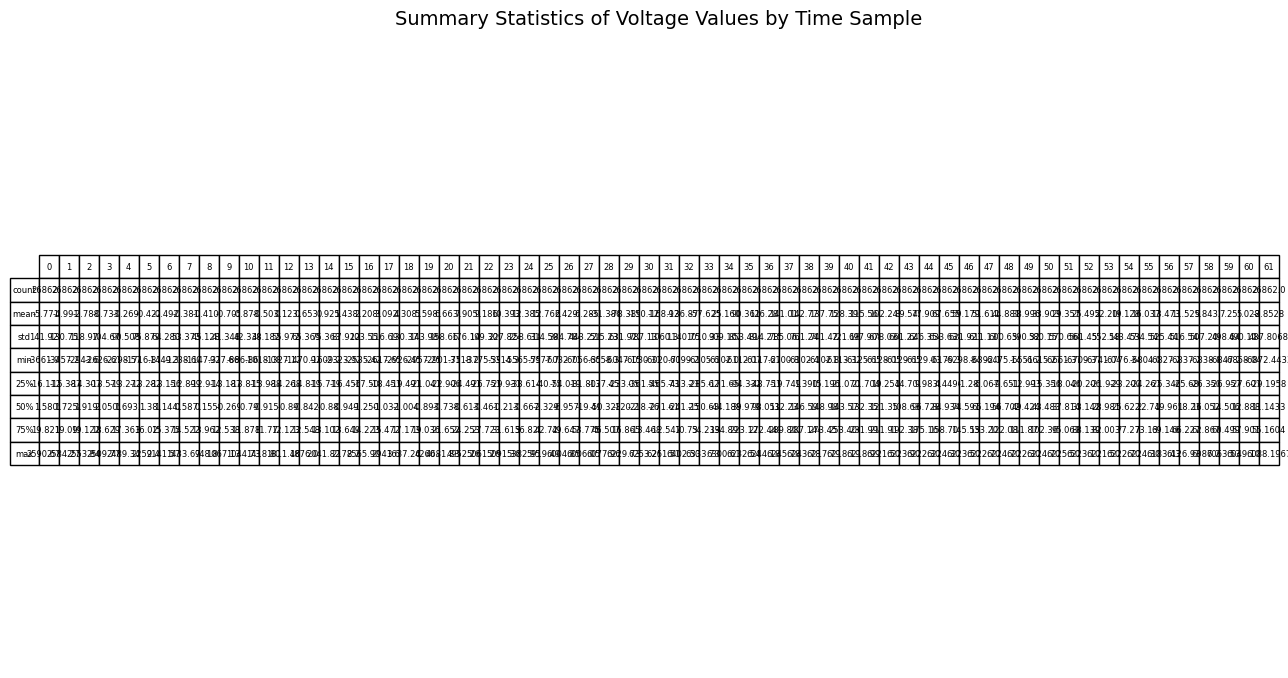

Saved: ../outputs/initial_plots_tiff/01_summary_statistics_by_time_sample.tiff


In [5]:
# Summary statistics for raw voltage values

summary_stats = df.describe().round(4)

display(summary_stats)

# Export summary statistics as TIFF
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis("off")

table = ax.table(
    cellText=summary_stats.values,
    rowLabels=summary_stats.index,
    colLabels=summary_stats.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(6)
table.scale(1.0, 1.4)

ax.set_title(
    "Summary Statistics of Voltage Values by Time Sample",
    fontsize=14,
    pad=20
)

output_path = os.path.join(
    tiff_output_dir,
    "01_summary_statistics_by_time_sample.tiff"
)

fig.savefig(
    output_path,
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", output_path)


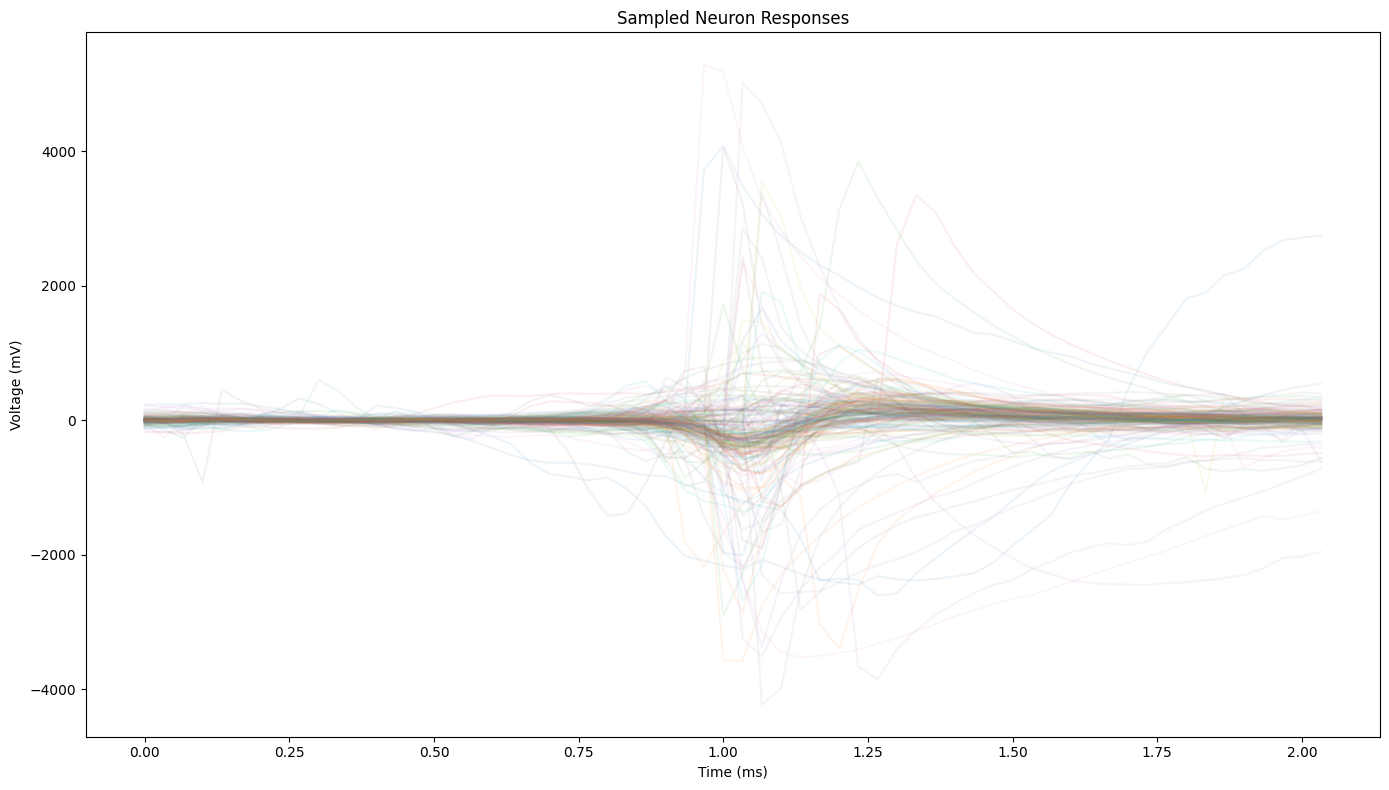

Saved: ../outputs/initial_plots_tiff/02_sampled_neuron_responses.tiff


In [6]:
# Plot sampled neuron responses

fig = plt.figure(figsize=(14, 8))

sample_rows = np.random.choice(
    df.index,
    200,
    replace=False
)

for row in sample_rows:
    plt.plot(
        time_ms,
        df.iloc[row, :],
        alpha=0.08,
        linewidth=1.5
    )

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Sampled Neuron Responses")
plt.tight_layout()

output_path = os.path.join(
    tiff_output_dir,
    "02_sampled_neuron_responses.tiff"
)

fig.savefig(
    output_path,
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", output_path)


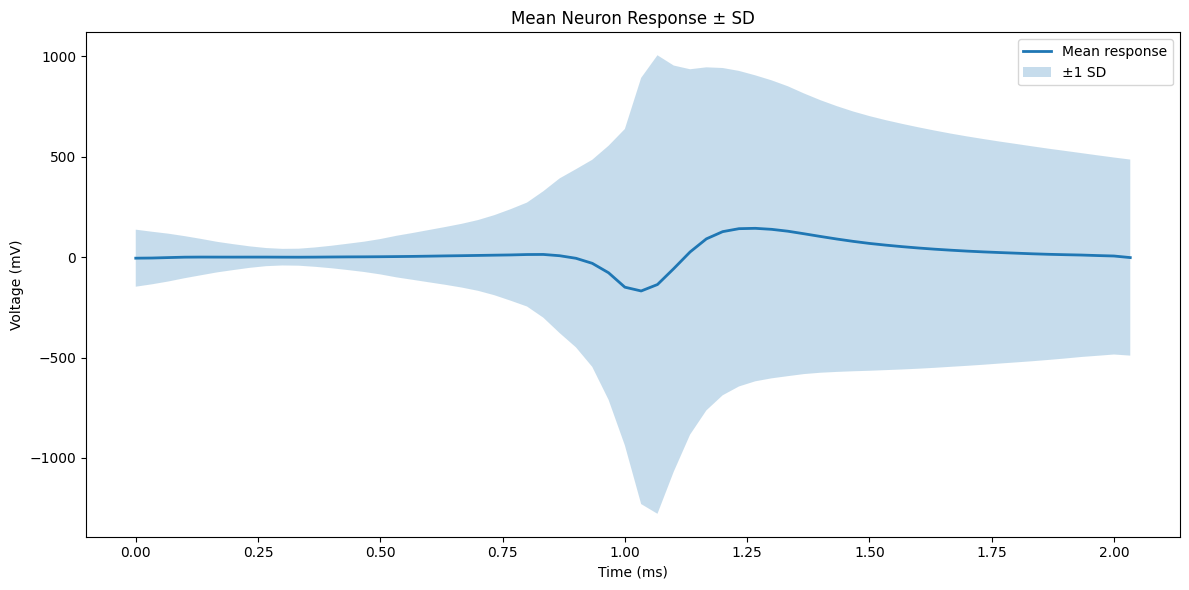

Saved: ../outputs/initial_plots_tiff/03_mean_neuron_response_sd.tiff


In [7]:
# Mean neuron response

mean_waveform = df.mean(axis=0)
std_waveform = df.std(axis=0)

fig = plt.figure(figsize=(12, 6))

plt.plot(
    time_ms,
    mean_waveform,
    linewidth=2,
    label="Mean response"
)

plt.fill_between(
    time_ms,
    mean_waveform - std_waveform,
    mean_waveform + std_waveform,
    alpha=0.25,
    label="±1 SD"
)

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Mean Neuron Response ± SD")
plt.legend()
plt.tight_layout()

output_path = os.path.join(
    tiff_output_dir,
    "03_mean_neuron_response_sd.tiff"
)

fig.savefig(
    output_path,
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", output_path)


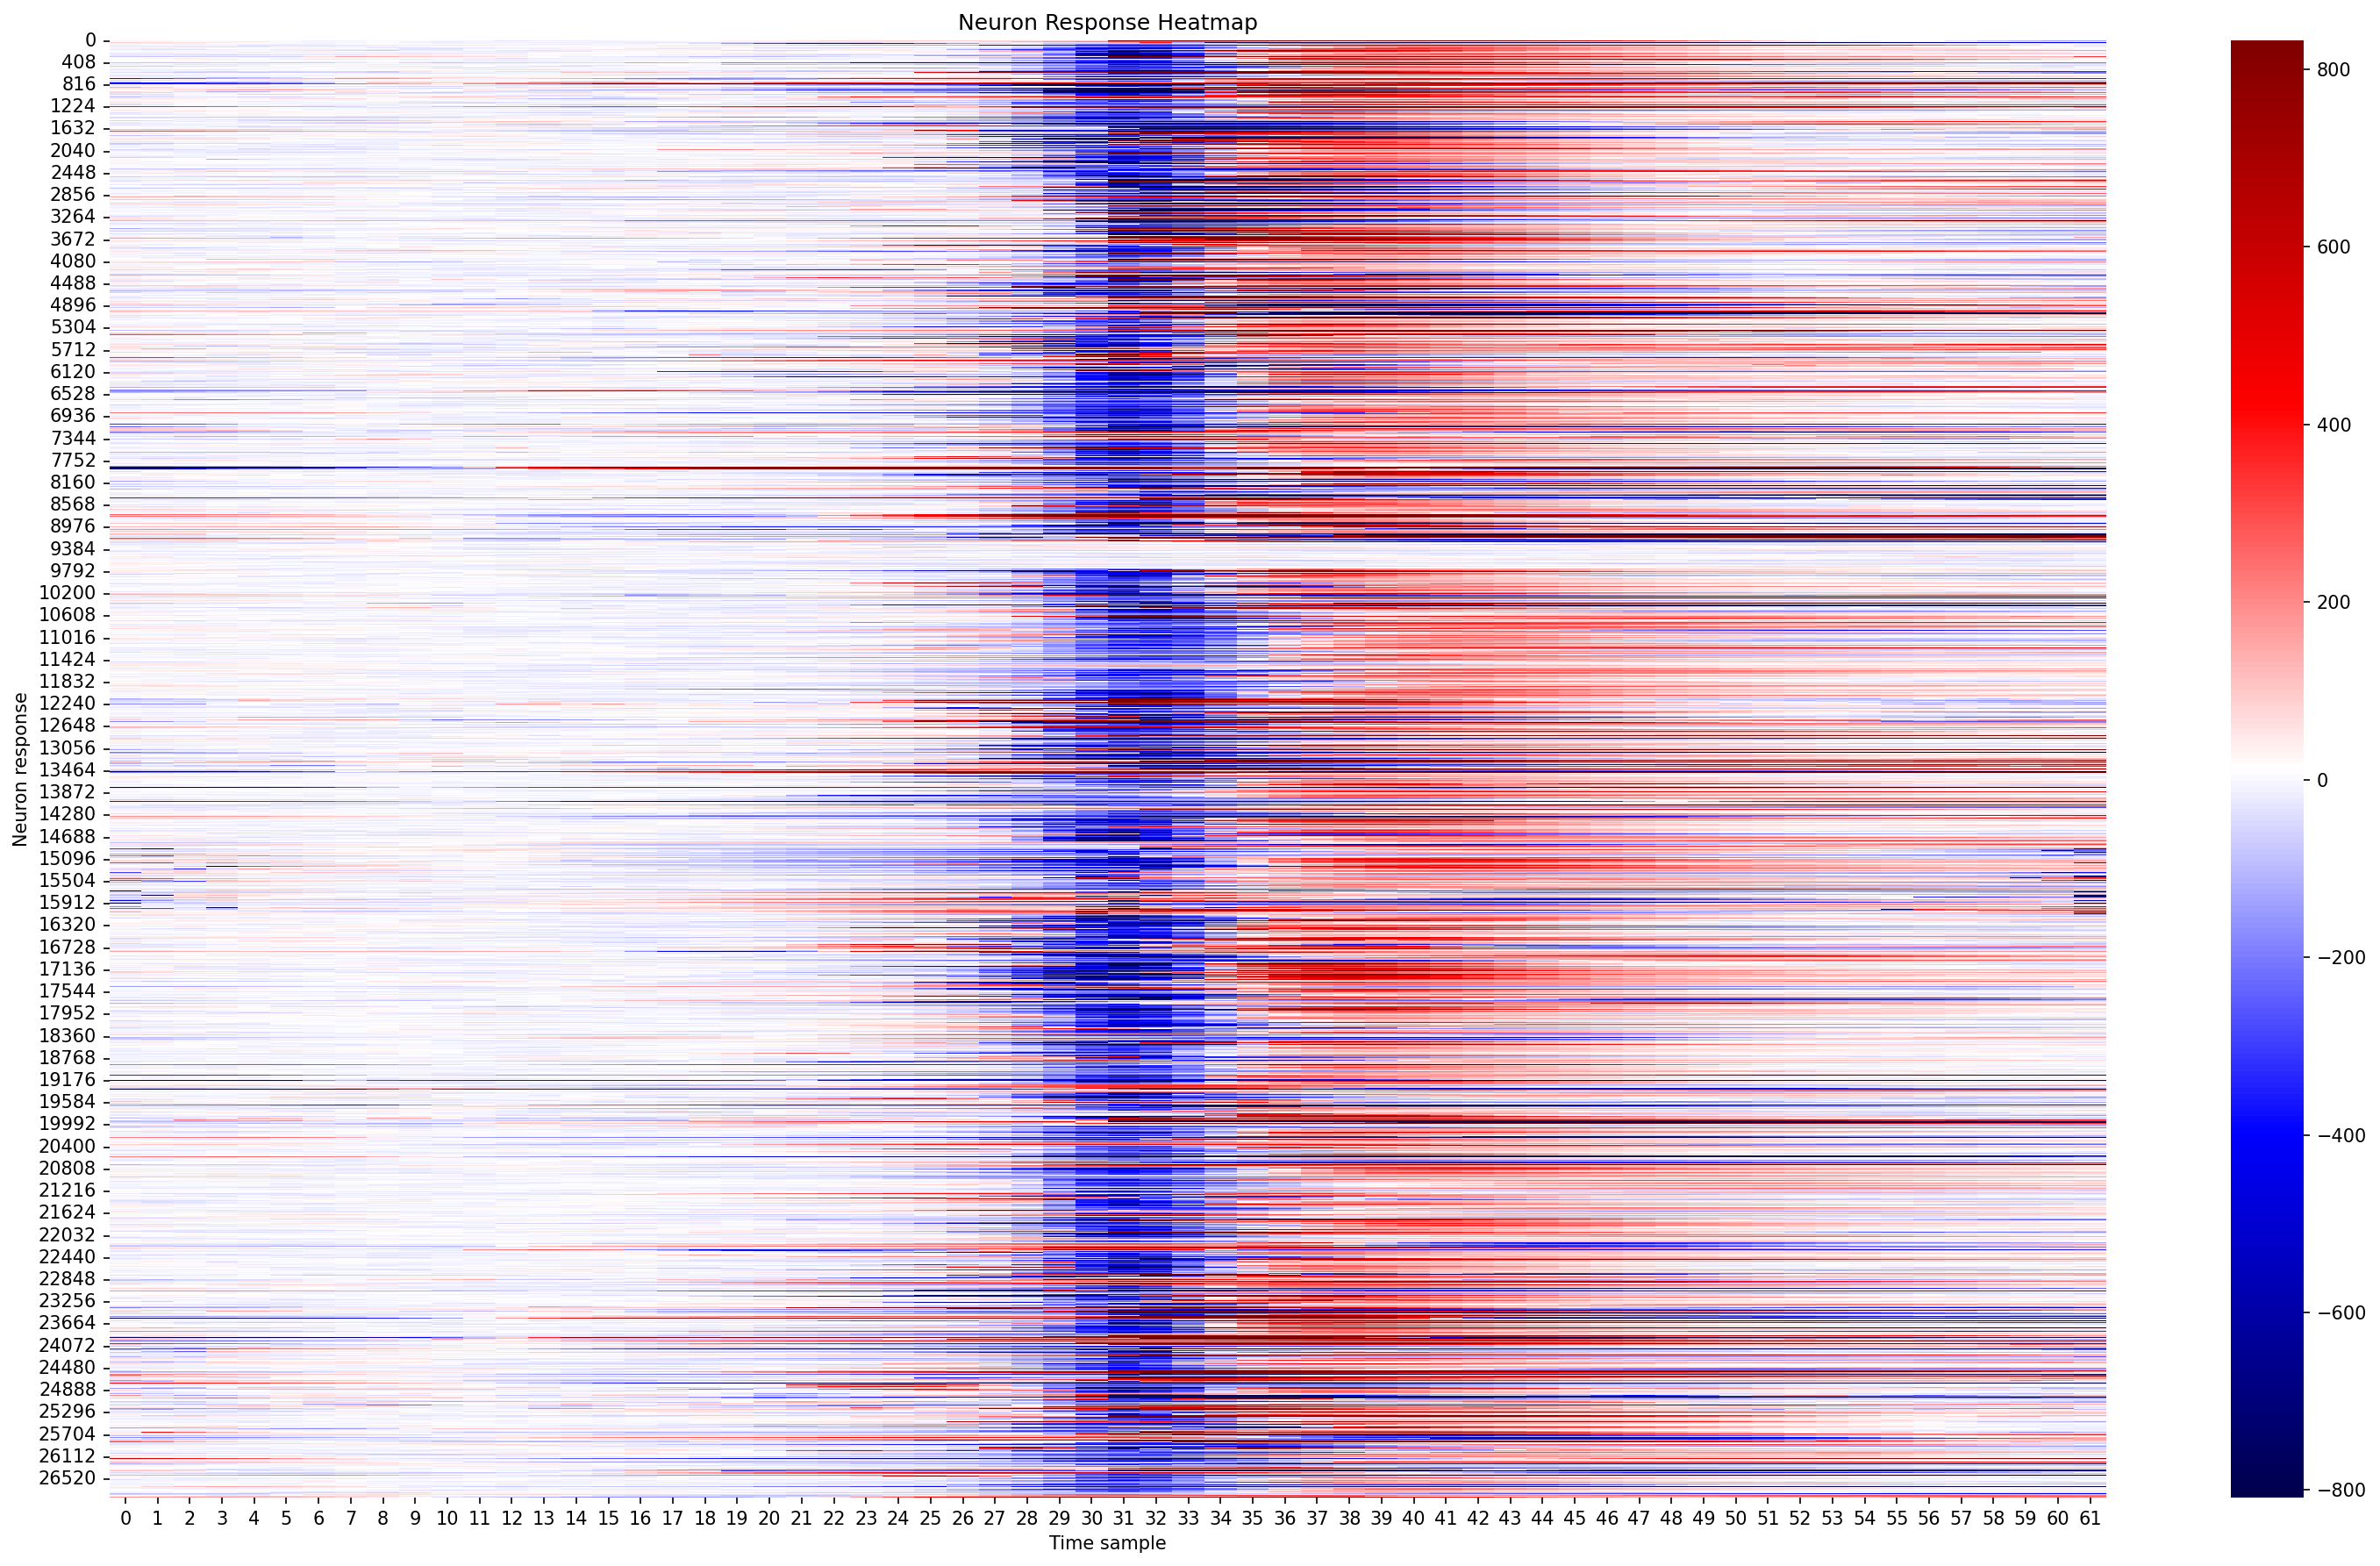

Saved: ../outputs/initial_plots_tiff/04_neuron_response_heatmap.tiff


In [8]:
# Heatmap

fig = plt.figure(figsize=(20, 12), dpi=150)

sns.heatmap(
    df,
    cmap="seismic",
    robust=True,
    cbar=True
)

plt.xlabel("Time sample")
plt.ylabel("Neuron response")
plt.title("Neuron Response Heatmap")
plt.tight_layout()

output_path = os.path.join(
    tiff_output_dir,
    "04_neuron_response_heatmap.tiff"
)

fig.savefig(
    output_path,
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", output_path)


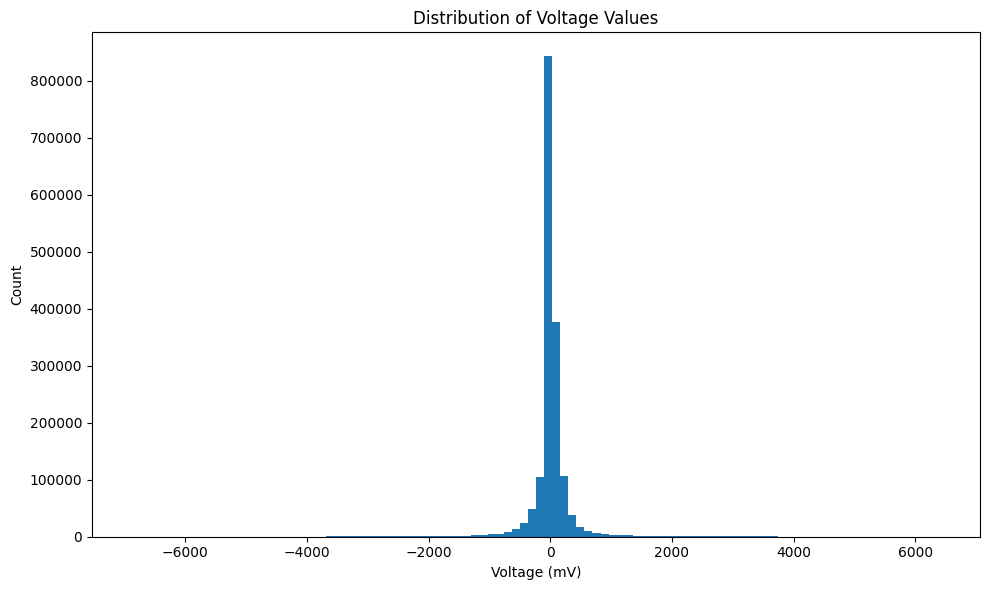

Saved: ../outputs/initial_plots_tiff/05_voltage_value_distribution.tiff


In [9]:
# Distribution of all voltage values

fig = plt.figure(figsize=(10, 6))

plt.hist(
    df.values.flatten(),
    bins=100
)

plt.xlabel("Voltage (mV)")
plt.ylabel("Count")
plt.title("Distribution of Voltage Values")
plt.tight_layout()

output_path = os.path.join(
    tiff_output_dir,
    "05_voltage_value_distribution.tiff"
)

fig.savefig(
    output_path,
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", output_path)


In [10]:
# Row-wise neuron response features

baseline_window = 5

baseline = df.iloc[:, :baseline_window].mean(axis=1)

min_value = df.min(axis=1)
max_value = df.max(axis=1)

min_sample = df.idxmin(axis=1).astype(int)
max_sample = df.idxmax(axis=1).astype(int)

min_time_ms = time_ms[min_sample]
max_time_ms = time_ms[max_sample]

peak_to_peak = max_value - min_value

mean_value = df.mean(axis=1)
std_value = df.std(axis=1)

negative_peak_abs = min_value.abs()
positive_peak_abs = max_value.abs()

dominant_polarity = np.where(
    positive_peak_abs > negative_peak_abs,
    "positive",
    "negative"
)

biphasic = (
    (min_value < 0) &
    (max_value > 0)
)

features_df = pd.DataFrame({
    "baseline_mV": baseline,
    "min_mV": min_value,
    "max_mV": max_value,
    "peak_to_peak_mV": peak_to_peak,
    "mean_mV": mean_value,
    "std_mV": std_value,
    "time_to_min_ms": min_time_ms,
    "time_to_max_ms": max_time_ms,
    "dominant_polarity": dominant_polarity,
    "biphasic": biphasic
})

display(features_df.head())


,baseline_mV,min_mV,max_mV,peak_to_peak_mV,mean_mV,std_mV,time_to_min_ms,time_to_max_ms,dominant_polarity,biphasic
0,13.861667,-140.758333,3392.475,3533.233333,436.162634,830.783209,2.033333,1.033333,positive,True
1,14.436667,-304.643333,382.590,687.233333,25.824409,140.462249,0.900000,1.133333,positive,True
2,-21.075000,-230.988333,299.845,530.833333,35.957366,113.983199,0.866667,1.133333,positive,True
3,-13.931667,-323.471667,260.295,583.766667,11.577796,114.042557,0.900000,1.166667,negative,True
4,5.731667,-366.855000,171.345,538.200000,-16.404462,81.777585,1.033333,1.166667,negative,True


Saved waveform features:
../outputs/waveform_features.csv


,baseline_mV,min_mV,max_mV,peak_to_peak_mV,mean_mV,std_mV,time_to_min_ms,time_to_max_ms
count,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000,26862.0000
mean,-2.9109,-635.2814,595.1413,1230.4227,17.1909,267.9999,1.0771,1.2097
std,111.5661,871.3626,1001.8847,1286.4109,301.6722,346.0721,0.3504,0.3592
min,-2868.0767,-6872.4433,7.4800,53.6735,-3527.3812,14.0984,0.0000,0.0000
25%,-12.0817,-614.7671,159.6000,471.1333,-8.3485,99.7673,1.0000,1.0667
50%,1.4075,-360.0483,255.3803,701.0667,9.9190,144.7962,1.0333,1.2333
75%,15.5592,-222.3538,467.0112,1360.2000,32.1739,261.1094,1.0667,1.3667
max,2545.5833,-6.4260,6402.5033,8005.0000,3425.2597,3157.1457,2.0333,2.0333


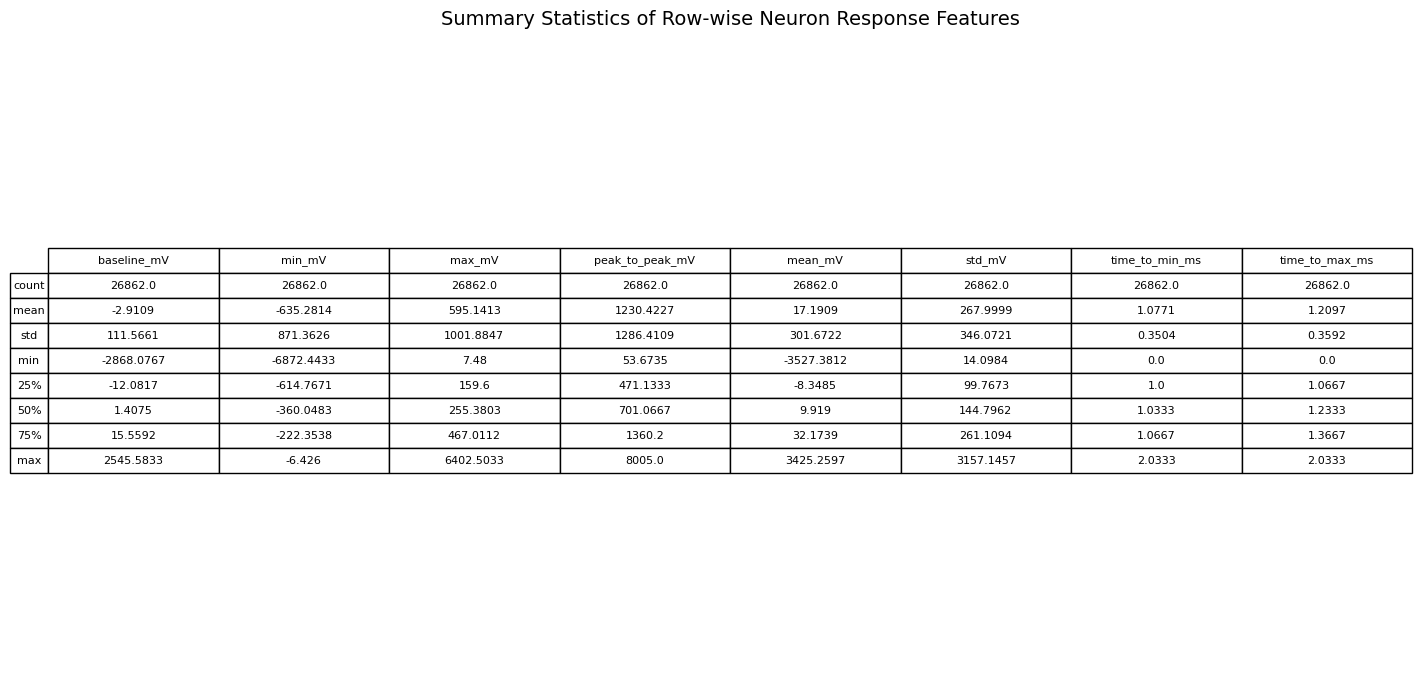

Saved: ../outputs/initial_plots_tiff/06_row_wise_feature_summary_statistics.tiff


In [11]:
# Save row-wise features and export feature summary as TIFF

features_output = "../outputs/waveform_features.csv"

features_df.to_csv(
    features_output,
    index=False
)

print("Saved waveform features:")
print(features_output)


feature_summary = features_df.describe().round(4)

display(feature_summary)

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis("off")

table = ax.table(
    cellText=feature_summary.values,
    rowLabels=feature_summary.index,
    colLabels=feature_summary.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.1, 1.5)

ax.set_title(
    "Summary Statistics of Row-wise Neuron Response Features",
    fontsize=14,
    pad=20
)

output_path = os.path.join(
    tiff_output_dir,
    "06_row_wise_feature_summary_statistics.tiff"
)

fig.savefig(
    output_path,
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Saved:", output_path)


In [ ]:
# List exported TIFF files

exported_files = sorted(
    file for file in os.listdir(tiff_output_dir)
    if file.endswith(".tiff")
)

for file in exported_files:
    print(
        os.path.join(tiff_output_dir, file)
    )
